> ## Роль в pipeline
>
> **Назначение:** main Health Score notebook — расчёт метрики качества на реальных данных.
>
> **Статус:** **active**. Source-of-truth для логики, которую нужно вынести в `src/metric/health_score.py` (P1 задача фреймворка).
>
> **Связь с другими ноутбуками:**
> - `weight_calibration_consensus.ipynb` — производит веса фичей внутри групп (PC1 / OptMin); сейчас НЕ интегрированы (внутри групп используется `np.mean`)
> - `weight_calibration_delta.ipynb` — research-инструмент для понимания совместимости таргетов; не источник весов
> - `weight_calibration.ipynb` — deprecated (циркулярная supervised калибровка)

---

## Что отражает метрика

Health Score — это **относительное отклонение** поведения пользователей за `today` относительно `baseline`-периода, агрегированное по нескольким независимым осям качества.

### Что метрика **ловит**

| Ось | Группа | Вес | Метрики |
|---|---|---|---|
| Качество поиска и пути | quality | 0.40 | `dead_search_rate ↓`, `search_refinement_rate ↓`, `bounce_rate ↓`, `km_median_time_to_cart_s ↓`, `complex_query_rate ↓` (NLP-pending), `in_product_base_rate ↑` (NLP-pending) |
| Engagement | engagement | 0.35 | `rate_clicks ↑`, `rate_views ↑`, `rate_favs ↑`, `multi_category_rate ↑`, `click_per_view ↑`, `cart_per_click ↑`, `cart_rate ↑`, `session_conversion_rate ↑` |
| Discovery | discovery | 0.25 | `rate_unique_queries ↑`, `rate_searches ↑`, `view_per_search ↑` |

Итого **17 фичей** (15 implemented + 2 NLP-pending). Внутри группы — `np.mean` (P1: заменить на consensus PC1/OptMin per `docs/weight_calibration_consensus.md`).

### Что метрика **НЕ ловит** (известные пробелы)

- **Retention** — возвращаются ли пользователи через 1/7/30 дней (отложено, см. `docs/weight_calibration_consensus.md`)
- **Query semantics** — `complex_query_rate`, `in_product_base_rate` ждут NLP-обогащения intent_sessions от `src/nlp/post-stratification.ipynb`
- **Distribution shape** — сравниваем только средние; форма (мультимодальность, тяжёлые хвосты) теряется
- **Time-of-day patterns** — день агрегируется целиком, паттерны 24/7 не видны

### Что метрика **игнорирует by design**

- **Абсолютный уровень** — мы смотрим только относительное движение к baseline (ratio-метрика). Если cart_rate всегда был 15% и стал 16% — это рост, неважно что 16% «низкое» по индустрии.
- **Состав трафика** — `stratified`-версия применяет фиксированные baseline-веса категорий, чтобы изолировать «эффект движка» от «эффекта пришли другие пользователи»
- **Боты как отдельный fix** — вместо фильтрации session-/user-level применяется bot-robust агрегация (ratio-к-baseline + stratification + MAD); см. `bot_filter.ipynb` 1.4 для исследования fil-логики, в production она НЕ применяется

---

## Как использовать в pipeline

### Daily запуск
1. Pipeline `build_day_summary.py` обновляет `data/daily_summaries/day_summary_YYYY_MM_DD.parquet`
2. Этот ноутбук читает все файлы, разбивает на `baseline` (28+ дней) и `today` (один день)
3. Считает `health_score_raw` (что произошло) и `health_score_stratified` (что от движка)
4. Считает MAD-thresholds → выдаёт алерты, где сегодня вышли за коридор
5. Сводка в section 7

### Чтение результата
- `health_score = 100` — норма (как baseline)
- `health_score = 95` — деградация на 5%
- `drift_signal = stratified - raw` положительный → сегодня тяжёлый трафик, движок на самом деле работает лучше, чем кажется по raw
- Если алерт сработал в одной группе — root cause в этой группе

### Decomposition для root cause
- `quality_score` упал → проблема в поиске или ранжировании
- `engagement_score` упал → пользователи теряют интерес (рекомендатель/UX)
- `discovery_score` упал → люди меньше ищут (входной трафик / SEO)

### Когда метрика **ненадёжна**
- < 28 дней baseline → MAD-thresholds нестабильны, алерты шумные
- Малая категория (`n_sessions < 100`) → высокая дисперсия per-category, лучше использовать ALL
- Сегодня — выходной/праздник → DoW-baseline (раздел 5.3) обязателен; raw сравнение даст false alert

---


# Метрика качества движка маркетплейса

Реализация по `metric_collection.pdf`.

---

## Зачем нужна эта метрика

Движок маркетплейса (поиск, ранжирование, рекомендации) влияет на поведение пользователей,
но наблюдаемые метрики смешивают **два эффекта**:

- **Эффект движка** — качество выдачи изменилось из-за релиза
- **Эффект трафика** — сегодня пришли другие пользователи с другими запросами

Без разделения этих эффектов нельзя ответить на вопрос: «релиз сломал продукт или просто
в понедельник после праздников трафик другой?»

---

## Архитектура решения

```
Сырые сессии (session-level)
        │
        ▼
compute_metrics()          ← flat dict всех метрик за день/категорию
        │
        ├── Активность      rate_events, rate_searches, ...
        ├── Конверсии        cart_rate, click_rate, ...
        ├── Funnel           search_success_rate ← ГЛАВНОЕ
        ├── Anti-metrics     bounce_rate, dead_search_rate, ...
        └── Перцентили       time_to_cart_p50, ...
        │
        ▼
compute_health_score()     ← index relative to baseline, 4 группы с весами
        │
        ├── raw score        (все сессии, без поправки на состав трафика)
        └── stratified score (взвешено по baseline-долям категорий)
        │
        ▼
Statistical confidence
        ├── CI95%            (насколько точна оценка)
        ├── MAD alerting     (выход за нормальный коридор)
        ├── DoW baseline     (сравнение с тем же днём недели)
        └── MDE              (какой минимальный эффект детектируем)
```

---

## Структура ноутбука

| # | Секция | Что делает |
|---|--------|-----------|
| 2 | Функции метрик | `compute_metrics()` — все 20+ метрик |
| 3 | Health Score | Индекс относительно baseline, веса групп |
| 4 | Stratified aggregation | Нейтрализация дрейфа категориального состава |
| 5 | Statistical confidence | CI, MAD-alerting, DoW, MDE |
| 6 | Визуализация | Временной ряд с порогами алертинга |
| 7 | Итоговая сводка | Все ключевые числа в одном месте |

> **Подключение реальных данных:** заменить `generate_sessions()` на чтение из
> `data/intent_sessions.parquet` с теми же именами колонок.

In [1]:
import polars as pl
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('OK')

OK


## 1. Данные: daily_summaries

Источник: `data/daily_summaries/` — 61 файл parquet, каждый = один день, строки = категории. Pipeline: `src/pipeline/build_day_summary.py`.

### Схема (22 колонки)

| Колонка | Тип | Описание |
|---|---|---|
| `date` | Date | Дата |
| `category` | String | Категория |
| `n_users` | UInt32 | Уникальных пользователей |
| `n_sessions` | UInt32 | Число сессий |
| **Per-session rates** | | |
| `rate_events` | Float64 | Среднее событий на сессию |
| `rate_searches` | Float64 | Среднее поисков на сессию |
| `rate_views` | Float64 | Среднее просмотров на сессию |
| `rate_clicks` | Float64 | Среднее кликов на сессию |
| `rate_favs` | Float64 | Среднее избранных на сессию |
| `rate_unique_queries` | Float64 | Среднее уникальных запросов на сессию |
| `cart_rate` | Float64 | `mean(n_cart)` per session — event-based |
| `mean_duration_s` | Float64 | Средняя длительность сессии (сек) |
| **Конверсии и quality** | | |
| `is_cart` | Int32 | Число сессий с корзиной (`sum(reached_cart)`) |
| `session_conversion_rate` | Float64 | `mean(reached_cart)` — binary конверсия |
| `bounce_rate` | Float64 | Доля однособытийных сессий |
| `dead_search_rate` | Float64 | `P(no click \| n_search > 0)` |
| `search_refinement_rate` | Float64 | `P(>1 query \| n_search > 0)` |
| `multi_category_rate` | Float64 | Доля кросс-категорийных сессий |
| **Funnel transitions** | | |
| `view_per_search` | Float64 | `sum(n_view)/sum(n_search)` |
| `click_per_view` | Float64 | `sum(n_click)/sum(n_view)` |
| `cart_per_click` | Float64 | `sum(n_cart)/sum(n_click)` |
| **Survival** | | |
| `km_median_time_to_cart_s` | Float64 | KM-медиана времени до корзины |

### Pending (NLP-обогащение)

`complex_query_rate`, `in_product_base_rate` — описаны в `docs/weight_calibration_consensus.md` как часть quality, но требуют NLP-расширения intent_sessions от ветки `nlp` (поля `query_stratification_score`, `is_in_product_base` от `src/nlp/post-stratification.ipynb`).

### Разбивка baseline / today

- **Baseline** — 2024-03-01 → 2024-03-31 (31 день)
- **Today** — 2024-04-01

In [2]:
import os

# Загружаем все файлы daily_summaries
summary_dir = '../../data/daily_summaries'
files = sorted(f for f in os.listdir(summary_dir) if f.endswith('.parquet'))

daily_df = (
    pl.concat([pl.read_parquet(f'{summary_dir}/{f}') for f in files])
    .with_columns(pl.col('date').cast(pl.Date))
    .to_pandas()
)
daily_df['date'] = pd.to_datetime(daily_df['date'])

BASELINE_START = pd.Timestamp('2024-03-01')
BASELINE_END   = pd.Timestamp('2024-03-31')
TODAY_DATE     = pd.Timestamp('2024-04-01')

baseline_df = daily_df[
    (daily_df['date'] >= BASELINE_START) & (daily_df['date'] <= BASELINE_END)
].copy()

today_df = daily_df[daily_df['date'] == TODAY_DATE].copy()

print(f'Всего строк:   {len(daily_df):,}  ({daily_df["date"].min().date()} – {daily_df["date"].max().date()})')
print(f'Baseline:      {len(baseline_df):,} строк, {baseline_df["date"].nunique()} дней')
print(f'Today (04-01): {len(today_df)} категорий')
today_df.head(3)

Всего строк:   28,242  (2024-03-01 – 2024-04-30)
Baseline:      14,352 строк, 31 дней
Today (04-01): 463 категорий


,date,category,n_users,n_sessions,rate_events,rate_searches,rate_views,rate_clicks,rate_favs,rate_unique_queries,...,session_conversion_rate,bounce_rate,dead_search_rate,search_refinement_rate,mean_duration_s,multi_category_rate,view_per_search,click_per_view,cart_per_click,km_median_time_to_cart_s
14352,2024-04-01,1 ступень кормления,406,424,25.424528,1.794811,22.186321,0.808962,0.030660,1.648585,...,0.410377,0.0,0.568396,0.330189,141.764151,0.752358,12.361367,0.036462,0.746356,81.0
14353,2024-04-01,2 ступень кормления,151,153,10.450980,1.418301,8.189542,0.392157,0.006536,1.294118,...,0.418301,0.0,0.725490,0.209150,50.039216,0.620915,5.774194,0.047885,1.133333,26.0
14354,2024-04-01,3 ступень кормления,201,208,11.754808,1.567308,9.129808,0.394231,0.028846,1.447115,...,0.447115,0.0,0.725962,0.278846,84.778846,0.471154,5.825153,0.043181,1.609756,21.0


## 2. Функции расчёта метрик

`compute_metrics(df)` принимает подмножество `daily_summaries` и возвращает плоский словарь
взвешенных метрик. Вес = `n_sessions`, null-aware (см. `wmean`).

### Маппинг метрик в группы Health Score

| Метрика | Группа | Direction |
|---|---|---|
| `dead_search_rate` | quality | ↓ (anti) |
| `search_refinement_rate` | quality | ↓ (anti) |
| `bounce_rate` | quality | ↓ (anti) |
| `km_median_time_to_cart_s` | quality | ↓ (anti) |
| `complex_query_rate` (NLP-pending) | quality | ↓ (anti) |
| `in_product_base_rate` (NLP-pending) | quality | ↑ |
| `rate_clicks` | engagement | ↑ |
| `rate_views` | engagement | ↑ |
| `rate_favs` | engagement | ↑ |
| `multi_category_rate` | engagement | ↑ |
| `click_per_view` | engagement | ↑ |
| `cart_per_click` | engagement | ↑ |
| `cart_rate` | engagement | ↑ |
| `session_conversion_rate` | engagement | ↑ |
| `rate_unique_queries` | discovery | ↑ |
| `rate_searches` | discovery | ↑ |
| `view_per_search` | discovery | ↑ |
| `mean_duration_s` | — (не в скоре) | амбивалентно |
| `rate_events` | — (не в скоре) | контекст |

In [3]:
def compute_metrics(df: pd.DataFrame) -> dict:
    """
    Считает метрики из daily_summary (строки date × category).
    Агрегирует взвешенно по n_sessions. Null-значения исключаются из знаменателя.
    Возвращает плоский dict, готовый к подаче в compute_health_score.
    """
    if len(df) == 0:
        return {}

    total_sessions = int(df['n_sessions'].sum())
    total_users    = int(df['n_users'].sum())
    total_is_cart  = int(df['is_cart'].sum())

    def wmean(col):
        if col not in df.columns:
            return np.nan
        if total_sessions == 0:
            return np.nan
        mask = df[col].notna()
        if not mask.any():
            return np.nan
        w = df.loc[mask, 'n_sessions']
        return float((df.loc[mask, col] * w).sum() / w.sum())

    return {
        # Volume
        'n_sessions':                total_sessions,
        'n_users':                   total_users,
        # quality (anti-metrics ↓)
        'dead_search_rate':          wmean('dead_search_rate'),
        'search_refinement_rate':    wmean('search_refinement_rate'),
        'bounce_rate':               wmean('bounce_rate'),
        'km_median_time_to_cart_s':  wmean('km_median_time_to_cart_s'),
        # quality NLP-pending (если будут в parquet — посчитаются, иначе NaN)
        'complex_query_rate':        wmean('complex_query_rate'),
        'in_product_base_rate':      wmean('in_product_base_rate'),
        # engagement (включая funnel и conversion)
        'rate_clicks':               wmean('rate_clicks'),
        'rate_views':                wmean('rate_views'),
        'rate_favs':                 wmean('rate_favs'),
        'multi_category_rate':       wmean('multi_category_rate'),
        'click_per_view':            wmean('click_per_view'),
        'cart_per_click':            wmean('cart_per_click'),
        'cart_rate':                 wmean('cart_rate'),
        'session_conversion_rate':   total_is_cart / total_sessions if total_sessions > 0 else np.nan,
        # discovery (включая funnel)
        'rate_unique_queries':       wmean('rate_unique_queries'),
        'rate_searches':             wmean('rate_searches'),
        'view_per_search':           wmean('view_per_search'),
        # context (не в Health Score)
        'mean_duration_s':           wmean('mean_duration_s'),
        'rate_events':               wmean('rate_events'),
    }


baseline_metrics = compute_metrics(baseline_df)
today_metrics    = compute_metrics(today_df)

pd.DataFrame({'baseline': baseline_metrics, 'today': today_metrics}).round(4)

,baseline,today
n_sessions,4.839890e+06,133425.0000
n_users,4.745824e+06,130871.0000
dead_search_rate,5.583000e-01,0.5710
search_refinement_rate,5.718000e-01,0.5671
bounce_rate,3.500000e-02,0.0382
km_median_time_to_cart_s,2.505627e+02,208.6870
complex_query_rate,NaN,NaN
in_product_base_rate,NaN,NaN
rate_clicks,1.305800e+00,1.1853
rate_views,5.434010e+01,48.8546


## 3. Health Score: index relative to baseline

**Индекс относительно baseline:** `index_m = (m_today / m_baseline) × 100`.
Для anti-метрик инверсия: `200 - index` (меньше = лучше → выше 100).

### Группы и веса (3-уровневая схема)

Структура соответствует `docs/weight_calibration_consensus.md`. Внутри группы — `np.mean` (равные веса как baseline; на P1 заменим на consensus-веса PC1/OptMin).

| Группа | Вес | Метрики |
|--------|-----|---------|
| **quality** | 0.40 | `dead_search_rate ↓`, `search_refinement_rate ↓`, `bounce_rate ↓`, `km_median_time_to_cart_s ↓`, `complex_query_rate ↓` (NLP-pending), `in_product_base_rate ↑` (NLP-pending) |
| **engagement** | 0.35 | `rate_clicks`, `rate_views`, `rate_favs`, `multi_category_rate`, `click_per_view`, `cart_per_click`, `cart_rate`, `session_conversion_rate` |
| **discovery** | 0.25 | `rate_unique_queries`, `rate_searches`, `view_per_search` |

### Изменения vs прежняя версия

- `cart_rate` (event-based) и `session_conversion_rate` (binary) **теперь внутри Health Score** в engagement (раньше были «таргетами» supervised-калибровки)
- Добавлены **funnel conditional probabilities** (`view_per_search`, `click_per_view`, `cart_per_click`)
- NLP-фичи (`complex_query_rate`, `in_product_base_rate`) — placeholder в группах quality, считаются при наличии в parquet, иначе NaN

### Почему cart_rate / session_conversion_rate **внутри** скора

После перехода на consensus (unsupervised) циркулярность ушла — supervised-калибровка с этими таргетами больше не используется как production-метод. Validation-чисто через **LOO** (см. `weight_calibration_delta.ipynb`).

In [4]:
GROUPS = {
    'quality': {
        'metrics': [
            'dead_search_rate',
            'search_refinement_rate',
            'bounce_rate',
            'km_median_time_to_cart_s',
            # NLP-pending (compute_metrics возвращает NaN если колонок нет в parquet)
            'complex_query_rate',
            'in_product_base_rate',
        ],
        'weight':  0.40,
        'invert':  [
            'dead_search_rate',
            'search_refinement_rate',
            'bounce_rate',
            'km_median_time_to_cart_s',
            'complex_query_rate',
            # in_product_base_rate — НЕ anti (больше = лучше: запрос точно в каталоге)
        ],
    },
    'engagement': {
        'metrics': [
            'rate_clicks', 'rate_views', 'rate_favs', 'multi_category_rate',
            'click_per_view', 'cart_per_click',
            'cart_rate', 'session_conversion_rate',
        ],
        'weight':  0.35,
        'invert':  [],
    },
    'discovery': {
        'metrics': ['rate_unique_queries', 'rate_searches', 'view_per_search'],
        'weight':  0.25,
        'invert':  [],
    },
}


def index_metric(today_val, baseline_val, invert: bool = False) -> float:
    if baseline_val is None or np.isnan(baseline_val) or baseline_val == 0:
        return np.nan
    if today_val is None or np.isnan(today_val):
        return np.nan
    idx = (today_val / baseline_val) * 100
    return (200 - idx) if invert else idx


def compute_health_score(today: dict, baseline: dict, groups: dict) -> tuple:
    rows = []
    group_scores = {}

    for group_name, cfg in groups.items():
        indices = []
        for m in cfg['metrics']:
            inv = m in cfg['invert']
            idx = index_metric(today.get(m, np.nan), baseline.get(m, np.nan), invert=inv)
            rows.append({'group': group_name, 'metric': m,
                         'baseline': baseline.get(m), 'today': today.get(m),
                         'index': idx, 'inverted': inv})
            if not np.isnan(idx):
                indices.append(idx)

        group_score = np.mean(indices) if indices else np.nan
        group_scores[group_name] = (group_score, cfg['weight'])

    valid = [(s, w) for s, w in group_scores.values() if not np.isnan(s)]
    health_score = sum(s * w for s, w in valid) / sum(w for _, w in valid) if valid else np.nan

    df = pd.DataFrame(rows)
    df['group_score']  = df['group'].map({k: v[0] for k, v in group_scores.items()})
    df['group_weight'] = df['group'].map({k: v[1] for k, v in group_scores.items()})
    print(f'\n=== HEALTH SCORE: {health_score:.1f} (норма = 100) ===')
    print(f'    Отклонение от baseline: {health_score - 100:+.1f}')
    for g, (s, w) in group_scores.items():
        print(f'    {g:12s}: {s:.1f}  (вес {w})')
    return df.round(4), health_score


detail_df, health_score = compute_health_score(today_metrics, baseline_metrics, GROUPS)
detail_df


=== HEALTH SCORE: 98.5 (норма = 100) ===
    Отклонение от baseline: -1.5
    quality     : 101.5  (вес 0.4)
    engagement  : 97.5  (вес 0.35)
    discovery   : 95.1  (вес 0.25)


,group,metric,baseline,today,index,inverted,group_score,group_weight
0,quality,dead_search_rate,0.5583,0.5710,97.7227,True,101.5360,0.40
1,quality,search_refinement_rate,0.5718,0.5671,100.8234,True,101.5360,0.40
2,quality,bounce_rate,0.0350,0.0382,90.8854,True,101.5360,0.40
3,quality,km_median_time_to_cart_s,250.5627,208.6870,116.7127,True,101.5360,0.40
4,quality,complex_query_rate,NaN,NaN,NaN,True,101.5360,0.40
5,quality,in_product_base_rate,NaN,NaN,NaN,False,101.5360,0.40
6,engagement,rate_clicks,1.3058,1.1853,90.7698,False,97.5346,0.35
7,engagement,rate_views,54.3401,48.8546,89.9054,False,97.5346,0.35
8,engagement,rate_favs,0.0445,0.0412,92.4552,False,97.5346,0.35
9,engagement,multi_category_rate,0.7690,0.7578,98.5419,False,97.5346,0.35


## 4. Stratified aggregation по категориям

### Проблема: дрейф категориального состава

Предположим, что сегодня в трафике стало на 10% больше запросов из категории
«электроника» (сложные, технические — хуже конвертируют), и меньше из «косметики»
(простые, высокая конверсия). Обычный raw score просядет, **хотя движок не изменился**.

### Решение: фиксированные baseline-веса

Метрика считается **per-category**, затем агрегируется с весами, зафиксированными
на baseline-периоде:

```
score_final = Σ_cat( w_baseline[cat] × score[cat, today] )
```

где `w_baseline[cat]` — доля сессий категории в baseline (не меняется каждый день).

Это убирает влияние того, что сегодня «другой трафик», и изолирует эффект движка.

### Raw vs Stratified

Обе версии всегда живут **параллельно**:

- **Raw** — что реально произошло, включая дрейф трафика
- **Stratified** — эффект движка при «прочих равных»
- **Расхождение** = сигнал дрейфа: если `stratified >> raw`, значит сегодня
  пришло непропорционально много «тяжёлого» трафика

In [5]:
# Baseline-веса категорий: доля n_sessions каждой категории за весь baseline-период
baseline_cat_weights = (
    baseline_df.groupby('category')['n_sessions'].sum()
    / baseline_df['n_sessions'].sum()
).rename('w_baseline')

print('Топ-10 категорий по baseline-весу:')
print(baseline_cat_weights.sort_values(ascending=False).head(10).round(4))

Топ-10 категорий по baseline-весу:
category
other                             0.0693
Конфеты                           0.0184
Сухие корма                       0.0182
Спортивные батончики и печенье    0.0176
Густой йогурт                     0.0163
Подгузники-трусики                0.0161
Порционное                        0.0138
Чипсы                             0.0124
Полутвердый                       0.0118
Бисквитные и песочные             0.0108
Name: w_baseline, dtype: float64


In [6]:
def compute_stratified_health_score(
    today_df: pd.DataFrame,
    baseline_df: pd.DataFrame,
    cat_weights: pd.Series,
    groups: dict,
) -> float:
    cat_scores = {}

    for cat, w in cat_weights.items():
        today_cat    = today_df[today_df['category'] == cat]
        baseline_cat = baseline_df[baseline_df['category'] == cat]
        if len(today_cat) == 0 or len(baseline_cat) == 0:
            continue

        tm = compute_metrics(today_cat)
        bm = compute_metrics(baseline_cat)
        _, score = compute_health_score(tm, bm, groups)
        cat_scores[cat] = (score, w)

    stratified = sum(s * w for s, w in cat_scores.values()) / sum(w for _, w in cat_scores.values())
    raw = compute_health_score(today_metrics, baseline_metrics, groups)[1]

    print(f'Raw score:        {raw:.2f}')
    print(f'Stratified score: {stratified:.2f}')
    print(f'Расхождение:      {stratified - raw:+.2f}  (сигнал дрейфа трафика)')
    return stratified


stratified_score = compute_stratified_health_score(
    today_df, baseline_df, baseline_cat_weights, GROUPS
)


=== HEALTH SCORE: 104.3 (норма = 100) ===
    Отклонение от baseline: +4.3
    quality     : 108.7  (вес 0.4)
    engagement  : 103.0  (вес 0.35)
    discovery   : 99.1  (вес 0.25)

=== HEALTH SCORE: 89.2 (норма = 100) ===
    Отклонение от baseline: -10.8
    quality     : 91.2  (вес 0.4)
    engagement  : 82.8  (вес 0.35)
    discovery   : 95.0  (вес 0.25)

=== HEALTH SCORE: 106.7 (норма = 100) ===
    Отклонение от baseline: +6.7
    quality     : 100.6  (вес 0.4)
    engagement  : 118.5  (вес 0.35)
    discovery   : 99.8  (вес 0.25)

=== HEALTH SCORE: 102.3 (норма = 100) ===
    Отклонение от baseline: +2.3
    quality     : 115.2  (вес 0.4)
    engagement  : 96.8  (вес 0.35)
    discovery   : 89.2  (вес 0.25)

=== HEALTH SCORE: 107.5 (норма = 100) ===
    Отклонение от baseline: +7.5
    quality     : 116.4  (вес 0.4)
    engagement  : 109.3  (вес 0.35)
    discovery   : 90.6  (вес 0.25)

=== HEALTH SCORE: 94.8 (норма = 100) ===
    Отклонение от baseline: -5.2
    quality     : 


=== HEALTH SCORE: 105.1 (норма = 100) ===


    Отклонение от baseline: +5.1
    quality     : 108.5  (вес 0.4)
    engagement  : 105.0  (вес 0.35)
    discovery   : 99.7  (вес 0.25)

=== HEALTH SCORE: 100.7 (норма = 100) ===
    Отклонение от baseline: +0.7
    quality     : 102.5  (вес 0.4)
    engagement  : 101.5  (вес 0.35)
    discovery   : 96.8  (вес 0.25)

=== HEALTH SCORE: 90.6 (норма = 100) ===
    Отклонение от baseline: -9.4
    quality     : 96.2  (вес 0.4)
    engagement  : 88.8  (вес 0.35)
    discovery   : 84.3  (вес 0.25)

=== HEALTH SCORE: 95.8 (норма = 100) ===
    Отклонение от baseline: -4.2
    quality     : 99.9  (вес 0.4)
    engagement  : 91.0  (вес 0.35)
    discovery   : 96.0  (вес 0.25)

=== HEALTH SCORE: 103.9 (норма = 100) ===
    Отклонение от baseline: +3.9
    quality     : 90.4  (вес 0.4)
    engagement  : 110.2  (вес 0.35)
    discovery   : 116.6  (вес 0.25)

=== HEALTH SCORE: 99.8 (норма = 100) ===
    Отклонение от baseline: -0.2
    quality     : 103.3  (вес 0.4)
    engagement  : 96.8  (вес


=== HEALTH SCORE: 96.4 (норма = 100) ===
    Отклонение от baseline: -3.6
    quality     : 97.9  (вес 0.4)
    engagement  : 95.1  (вес 0.35)
    discovery   : 96.0  (вес 0.25)

=== HEALTH SCORE: 104.6 (норма = 100) ===
    Отклонение от baseline: +4.6
    quality     : 112.0  (вес 0.4)
    engagement  : 96.6  (вес 0.35)
    discovery   : 104.2  (вес 0.25)

=== HEALTH SCORE: 89.2 (норма = 100) ===
    Отклонение от baseline: -10.8
    quality     : 86.3  (вес 0.4)
    engagement  : 92.1  (вес 0.35)
    discovery   : 89.6  (вес 0.25)

=== HEALTH SCORE: 100.2 (норма = 100) ===
    Отклонение от baseline: +0.2
    quality     : 101.8  (вес 0.4)
    engagement  : 99.0  (вес 0.35)
    discovery   : 99.4  (вес 0.25)

=== HEALTH SCORE: 96.0 (норма = 100) ===
    Отклонение от baseline: -4.0
    quality     : 85.9  (вес 0.4)
    engagement  : 94.1  (вес 0.35)
    discovery   : 114.8  (вес 0.25)

=== HEALTH SCORE: 101.4 (норма = 100) ===
    Отклонение от baseline: +1.4
    quality     : 117.


=== HEALTH SCORE: 98.6 (норма = 100) ===
    Отклонение от baseline: -1.4
    quality     : 112.7  (вес 0.4)
    engagement  : 88.1  (вес 0.35)
    discovery   : 90.8  (вес 0.25)

=== HEALTH SCORE: 98.3 (норма = 100) ===
    Отклонение от baseline: -1.7
    quality     : 102.6  (вес 0.4)
    engagement  : 94.9  (вес 0.35)
    discovery   : 96.3  (вес 0.25)

=== HEALTH SCORE: 98.0 (норма = 100) ===
    Отклонение от baseline: -2.0
    quality     : 115.3  (вес 0.4)
    engagement  : 92.4  (вес 0.35)
    discovery   : 78.1  (вес 0.25)

=== HEALTH SCORE: 107.2 (норма = 100) ===
    Отклонение от baseline: +7.2
    quality     : 100.8  (вес 0.4)
    engagement  : 108.7  (вес 0.35)
    discovery   : 115.2  (вес 0.25)

=== HEALTH SCORE: 100.3 (норма = 100) ===
    Отклонение от baseline: +0.3
    quality     : 101.8  (вес 0.4)
    engagement  : 101.1  (вес 0.35)
    discovery   : 96.5  (вес 0.25)

=== HEALTH SCORE: 97.6 (норма = 100) ===
    Отклонение от baseline: -2.4
    quality     : 10

...


=== HEALTH SCORE: 118.2 (норма = 100) ===
    Отклонение от baseline: +18.2
    quality     : 103.4  (вес 0.4)
    engagement  : 132.8  (вес 0.35)
    discovery   : 121.4  (вес 0.25)

=== HEALTH SCORE: 92.5 (норма = 100) ===
    Отклонение от baseline: -7.5
    quality     : 99.7  (вес 0.4)
    engagement  : 84.5  (вес 0.35)
    discovery   : 92.1  (вес 0.25)

=== HEALTH SCORE: 99.6 (норма = 100) ===
    Отклонение от baseline: -0.4
    quality     : 104.1  (вес 0.4)
    engagement  : 94.2  (вес 0.35)
    discovery   : 99.9  (вес 0.25)

=== HEALTH SCORE: 104.7 (норма = 100) ===
    Отклонение от baseline: +4.7
    quality     : 118.3  (вес 0.4)
    engagement  : 90.6  (вес 0.35)
    discovery   : 102.5  (вес 0.25)

=== HEALTH SCORE: 87.5 (норма = 100) ===
    Отклонение от baseline: -12.5
    quality     : 102.9  (вес 0.4)
    engagement  : 73.3  (вес 0.35)
    discovery   : 82.7  (вес 0.25)

=== HEALTH SCORE: 97.6 (норма = 100) ===
    Отклонение от baseline: -2.4
    quality     : 1


=== HEALTH SCORE: 105.0 (норма = 100) ===


    Отклонение от baseline: +5.0
    quality     : 118.4  (вес 0.4)
    engagement  : 95.7  (вес 0.35)
    discovery   : 96.4  (вес 0.25)

=== HEALTH SCORE: 104.9 (норма = 100) ===
    Отклонение от baseline: +4.9
    quality     : 110.7  (вес 0.4)
    engagement  : 99.4  (вес 0.35)
    discovery   : 103.4  (вес 0.25)

=== HEALTH SCORE: 106.6 (норма = 100) ===
    Отклонение от baseline: +6.6
    quality     : 119.2  (вес 0.4)
    engagement  : 101.9  (вес 0.35)
    discovery   : 93.0  (вес 0.25)

=== HEALTH SCORE: 112.2 (норма = 100) ===
    Отклонение от baseline: +12.2
    quality     : 127.0  (вес 0.4)
    engagement  : 104.3  (вес 0.35)
    discovery   : 99.5  (вес 0.25)

=== HEALTH SCORE: 96.1 (норма = 100) ===
    Отклонение от baseline: -3.9
    quality     : 86.9  (вес 0.4)
    engagement  : 98.4  (вес 0.35)
    discovery   : 107.4  (вес 0.25)

=== HEALTH SCORE: 9.1 (норма = 100) ===
    Отклонение от baseline: -90.9
    quality     : -128.2  (вес 0.4)
    engagement  : 94.9 


=== HEALTH SCORE: 92.8 (норма = 100) ===


    Отклонение от baseline: -7.2
    quality     : 114.1  (вес 0.4)
    engagement  : 66.3  (вес 0.35)
    discovery   : 95.7  (вес 0.25)

=== HEALTH SCORE: 101.7 (норма = 100) ===
    Отклонение от baseline: +1.7
    quality     : 98.7  (вес 0.4)
    engagement  : 109.7  (вес 0.35)
    discovery   : 95.3  (вес 0.25)

=== HEALTH SCORE: 105.6 (норма = 100) ===
    Отклонение от baseline: +5.6
    quality     : 109.1  (вес 0.4)
    engagement  : 105.5  (вес 0.35)
    discovery   : 100.1  (вес 0.25)

=== HEALTH SCORE: 102.5 (норма = 100) ===
    Отклонение от baseline: +2.5
    quality     : 107.8  (вес 0.4)
    engagement  : 100.9  (вес 0.35)
    discovery   : 96.3  (вес 0.25)

=== HEALTH SCORE: 64.9 (норма = 100) ===
    Отклонение от baseline: -35.1
    quality     : 69.9  (вес 0.4)
    engagement  : 67.9  (вес 0.35)
    discovery   : 52.9  (вес 0.25)

=== HEALTH SCORE: 91.6 (норма = 100) ===
    Отклонение от baseline: -8.4
    quality     : 93.7  (вес 0.4)
    engagement  : 88.8  (в

## 5. Statistical Confidence

Метрика без оценки неопределённости — источник либо **ложных тревог**, либо
**пропущенных регрессий**. Этот раздел отвечает на вопросы:

1. **CI95%** — насколько точна сегодняшняя оценка метрики?
2. **MAD alerting** — выходит ли сегодняшнее значение за нормальный коридор?
3. **DoW baseline** — не сравниваем ли понедельник с субботой?
4. **MDE** — какой минимальный эффект метрика вообще способна заметить?

### 5.1 CI95% для session_conversion_rate

`session_conversion_rate = is_cart / n_sessions` — proportion-метрика (доля конвертированных сессий).
Для неё применима формула CI95% для пропорции. Остальные `rate_*` (включая event-based `cart_rate`) не пропорции — для них нужен bootstrap.

```
SE = sqrt( p × (1 - p) / n )
CI95% = p ± 1.96 × SE
```

In [7]:
def proportion_ci95(p: float, n: int) -> tuple:
    if n == 0 or np.isnan(p):
        return (np.nan, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    return (p - 1.96 * se, p + 1.96 * se)


p = today_metrics['session_conversion_rate']
n = today_metrics['n_sessions']
lo, hi = proportion_ci95(p, n)

pd.DataFrame([{
    'metric':   'session_conversion_rate',
    'value':    p,
    'ci_lo':    lo,
    'ci_hi':    hi,
    'ci_width': hi - lo,
}]).round(5)

,metric,value,ci_lo,ci_hi,ci_width
0,session_conversion_rate,0.4824,0.47972,0.48508,0.00536


### 5.2 Rolling baseline + MAD alerting

#### Почему не std?

Стандартное отклонение чувствительно к выбросам: один день с промоакцией или
инцидентом раздувает `std` и делает алерты слепыми на следующие 28 дней.

**MAD (Median Absolute Deviation)** устойчив к выбросам:

```
median_baseline = median(metric за последние 28 дней)
MAD             = median( |metric - median_baseline| )
threshold       = median_baseline ± 3 × 1.4826 × MAD
```

Коэффициент `1.4826` нормирует MAD так, чтобы для нормального распределения
он совпадал со стандартным отклонением. Множитель `3` даёт порог ~99.7% для
нормального шума.

#### Логика алерта

Если `today < threshold_lo` или `today > threshold_hi` → алерт.

Для anti-метрик (`bounce_rate`, `dead_search_rate`) алерт при `today > threshold_hi`
уже говорит о деградации — порог один и тот же, интерпретация разная.

In [8]:
daily_agg = (
    baseline_df.groupby('date')
    .apply(lambda g: pd.Series(compute_metrics(g)))
    .reset_index()
    .set_index('date')
)

ALERT_METRICS = ['dead_search_rate', 'search_refinement_rate', 'bounce_rate', 'rate_clicks']


def mad_thresholds(series: pd.Series, k: float = 3.0) -> tuple:
    med = series.median()
    mad = (series - med).abs().median()
    return med - k * 1.4826 * mad, med, med + k * 1.4826 * mad


alert_rows = []
for m in ALERT_METRICS:
    lo, med, hi = mad_thresholds(daily_agg[m])
    today_val = today_metrics[m]
    alert = not (lo <= today_val <= hi)
    alert_rows.append({
        'metric':           m,
        'baseline_median':  med,
        'threshold_lo':     lo,
        'threshold_hi':     hi,
        'today':            today_val,
        'ALERT':            '🔴 YES' if alert else '🟢 ok',
    })

pd.DataFrame(alert_rows).round(5)

,metric,baseline_median,threshold_lo,threshold_hi,today,ALERT
0,dead_search_rate,0.55965,0.54382,0.57549,0.57101,🟢 ok
1,search_refinement_rate,0.57298,0.56225,0.58372,0.56707,🟢 ok
2,bounce_rate,0.03553,0.02624,0.04481,0.03819,🟢 ok
3,rate_clicks,1.27184,1.10385,1.43982,1.18525,🟢 ok


### 5.3 Day-of-week (DoW) baseline

#### Проблема

Поведение пользователей систематически различается по дням недели:
- В выходные — больше браузинга, меньше целевых покупок → `cart_rate` ниже
- В понедельник после выходных — всплеск поиска → `rate_searches` выше

Если сравнивать сегодняшний понедельник с медианой за все 28 дней (включая субботы
и воскресенья), получим **до 80% ложных алертов** на выходных.

#### Решение

Сравнивать `today` только с историческими значениями **того же дня недели**:

```
same_dow_baseline = metric[date] for date in baseline where date.weekday == today.weekday
MAD-пороги строятся по same_dow_baseline
```

Недостаток: нужно минимум 4 значения каждого дня недели (4 недели baseline),
иначе пороги нестабильны.

In [9]:
daily_agg['dow'] = pd.to_datetime(daily_agg.index).dayofweek

today_dow = TODAY_DATE.dayofweek
same_dow  = daily_agg[daily_agg['dow'] == today_dow]

print(f'Today DoW: {today_dow} ({TODAY_DATE.day_name()})')
print(f'Baseline дней с тем же DoW: {len(same_dow)}')

dow_alert_rows = []
for m in ['dead_search_rate', 'search_refinement_rate', 'rate_clicks']:
    if len(same_dow) < 3:
        continue
    lo, med, hi = mad_thresholds(same_dow[m])
    today_val = today_metrics[m]
    alert = not (lo <= today_val <= hi)
    dow_alert_rows.append({
        'metric':              m,
        'dow_baseline_median': med,
        'dow_threshold_lo':    lo,
        'dow_threshold_hi':    hi,
        'today':               today_val,
        'ALERT':               '🔴 YES' if alert else '🟢 ok',
    })

pd.DataFrame(dow_alert_rows).round(5)

Today DoW: 0 (Monday)
Baseline дней с тем же DoW: 4


,metric,dow_baseline_median,dow_threshold_lo,dow_threshold_hi,today,ALERT
0,dead_search_rate,0.56313,0.56021,0.56606,0.57101,🔴 YES
1,search_refinement_rate,0.57158,0.56173,0.58143,0.56707,🟢 ok
2,rate_clicks,1.22365,1.18175,1.26554,1.18525,🟢 ok


### 5.4 Минимальный детектируемый эффект (MDE)

#### Зачем

MDE отвечает на вопрос: **«какое минимальное изменение метрики мы вообще способны
заметить при данном объёме данных?»**

```
MDE ≈ 2.8 × sqrt( 2 × p × (1 - p) / n )
```

Формула выведена из стандартного расчёта мощности теста при α=0.05, power=0.80.

#### Интерпретация `MDE_%`

`MDE_%` = MDE / p × 100 — относительный MDE в процентах от текущего значения.

- `MDE_% = 2%` → метрика замечает изменение на 2% и выше (чувствительная)
- `MDE_% = 15%` → метрика слепа к изменениям меньше 15% (ненадёжна в этом сегменте)

#### Практическое применение

Таблица MDE по сегментам сразу показывает:
- Где система чувствительна (ALL, крупные категории)
- Где алерты бесполезны — слишком мало данных (редкие категории, tail-запросы)

Для слепых сегментов нужно либо накапливать данные дольше (7-дневное окно),
либо не строить per-segment алерты вовсе.

In [10]:
def mde(p: float, n: int) -> float:
    if n == 0 or np.isnan(p):
        return np.nan
    return 2.8 * np.sqrt(2 * p * (1 - p) / n)


mde_rows = []

# По всей выборке (binary session conversion — для MDE нужна пропорция)
p = today_metrics['session_conversion_rate']
n = today_metrics['n_sessions']
mde_rows.append({'segment': 'ALL', 'p': p, 'n': n, 'MDE': mde(p, n), 'MDE_%': mde(p, n) / p * 100 if p else np.nan})

# По топ-категориям (только те, что есть в today)
for cat in sorted(today_df['category'].unique()):
    cat_rows = today_df[today_df['category'] == cat]
    cat_m = compute_metrics(cat_rows)
    p = cat_m['session_conversion_rate']
    n = cat_m['n_sessions']
    mde_rows.append({'segment': cat, 'p': p, 'n': n, 'MDE': mde(p, n), 'MDE_%': mde(p, n) / p * 100 if p else np.nan})

mde_df = pd.DataFrame(mde_rows).round(4)
print('Чем выше MDE_% — тем слепее метрика в этом сегменте')
mde_df.sort_values('MDE_%')

Чем выше MDE_% — тем слепее метрика в этом сегменте


,segment,p,n,MDE,MDE_%
0,ALL,0.4824,133425,0.0054,1.1229
88,Густой йогурт,0.7548,2496,0.0341,4.5174
301,Полутвердый,0.8047,1531,0.0401,4.9856
412,Туалетная бумага,0.7790,1606,0.0410,5.2636
302,Помидоры,0.8400,956,0.0470,5.5903
...,...,...,...,...,...
373,Спортивные товары для детей,0.0132,76,0.0518,393.3660
78,Головные уборы,0.0125,80,0.0492,393.4971
382,"Сумки, визитницы, ремни",0.0114,88,0.0447,393.7235
325,Ролевые наборы,0.0000,25,0.0000,NaN


## 6. Визуализация: динамика ключевых метрик

На каждом графике:
- **Синяя линия** — ежедневные значения метрики в baseline-периоде
- **Серый пунктир** — медиана baseline
- **Зелёная полоса** — нормальный коридор (MAD-пороги ±3σ)
- **Красная линия** — значение сегодня

Если красная линия выходит за зелёную полосу → алерт.

`dead_search_rate = 1 - search_success_rate`, поэтому они зеркальны — это намеренно:
оба показывают одно и то же явление с разных сторон для удобства интерпретации.

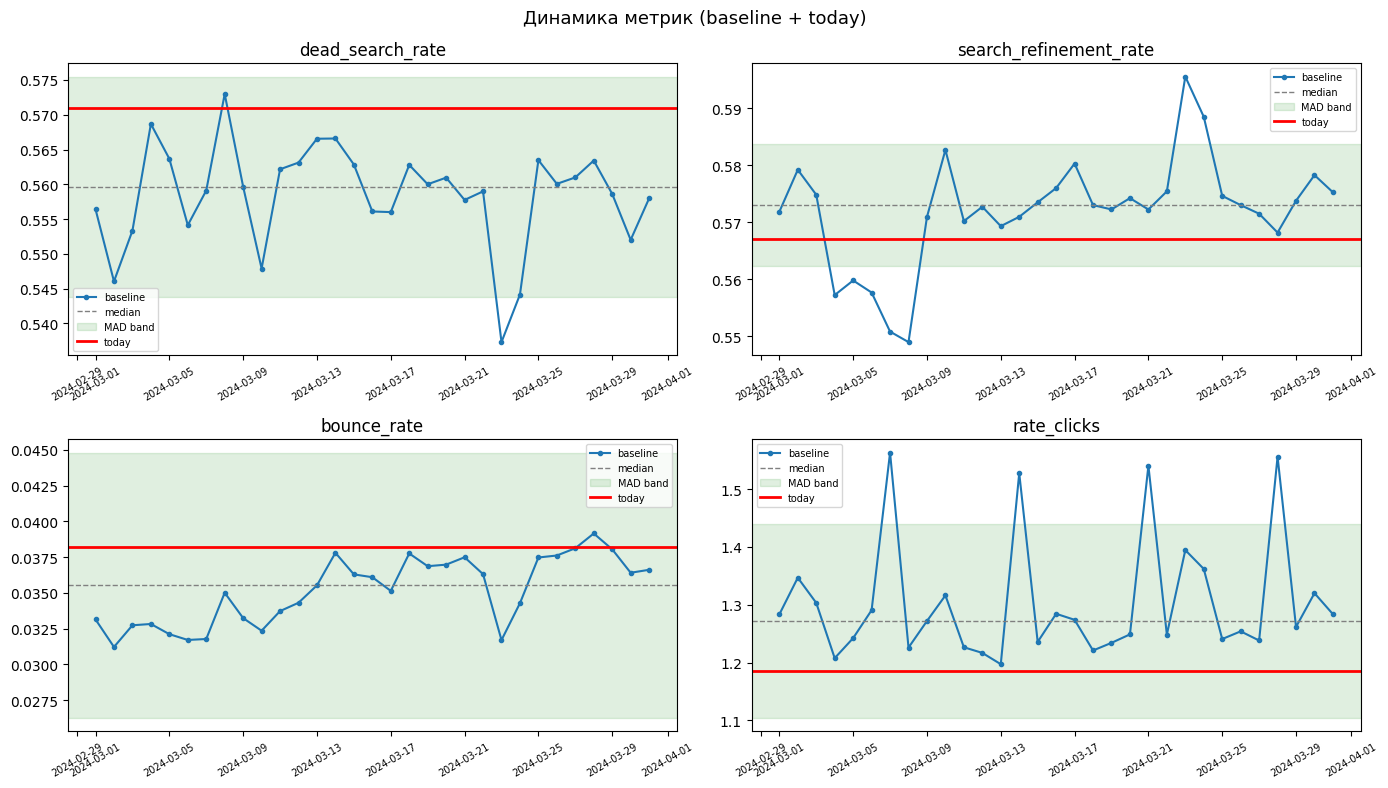

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Динамика метрик (baseline + today)', fontsize=13)

for ax, m in zip(axes.flat, ALERT_METRICS):
    series = daily_agg[m]
    lo, med, hi = mad_thresholds(series)

    ax.plot(series.index, series.values, marker='o', markersize=3, label='baseline')
    ax.axhline(med, color='gray', linestyle='--', linewidth=1, label='median')
    ax.axhspan(lo, hi, alpha=0.12, color='green', label='MAD band')
    ax.axhline(today_metrics[m], color='red', linewidth=2, label='today')
    ax.set_title(m)
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.tight_layout()
plt.show()

## 7. Итоговая сводка

| Поле | Описание |
|---|---|
| `health_score_raw` | Score без поправки на состав трафика. Показывает что реально произошло |
| `health_score_stratified` | Score с фиксированными baseline-весами категорий. Изолирует эффект движка |
| `drift_signal` | Разница `stratified - raw`. Положительное значение = сегодня тяжёлый трафик, движок на самом деле работает лучше, чем кажется по raw |
| `search_success_rate` | P(click\|search) — главная метрика качества search |
| `cart_rate` | Среднее добавлений в корзину на сессию (event-based) — главная коммерческая метрика |
| `bounce_rate` | Доля однособытийных сессий — ранний сигнал деградации |
| `dead_search_rate` | 1 - search_success_rate — зеркало главной метрики |

### Следующие шаги (из PDF, фаза 2–4)

- [x] Подключить реальные данные из `data/intent_sessions.parquet`


In [12]:
summary = {
    'health_score_raw':          round(health_score, 2),
    'health_score_stratified':   round(stratified_score, 2),
    'drift_signal':              round(stratified_score - health_score, 2),
    'cart_rate':                 round(today_metrics['cart_rate'], 4),
    'dead_search_rate':          round(today_metrics['dead_search_rate'], 4),
    'search_refinement_rate':    round(today_metrics['search_refinement_rate'], 4),
    'bounce_rate':               round(today_metrics['bounce_rate'], 4),
    'rate_clicks':               round(today_metrics['rate_clicks'], 4),
    'rate_unique_queries':       round(today_metrics['rate_unique_queries'], 4),
    'mean_duration_s':           round(today_metrics['mean_duration_s'], 1),
}

for k, v in summary.items():
    print(f'{k:35s}: {v}')

health_score_raw                   : 98.52
health_score_stratified            : 99.68
drift_signal                       : 1.16
cart_rate                          : 1.9026
dead_search_rate                   : 0.571
search_refinement_rate             : 0.5671
bounce_rate                        : 0.0382
rate_clicks                        : 1.1853
rate_unique_queries                : 3.1304
mean_duration_s                    : 288.4


## Roadmap: как апгрейдить метрику

### A. Новые фичи в `day_summary` (закрывают пробелы покрытия)

| Приоритет | Фича | Что закрывает | Сложность |
|---|---|---|---|
| 🔴 P1 | **Funnel conditional probs**: `view_per_search`, `click_per_view`, `cart_per_click` | декомпозиция воронки | низкая, ~1ч |
| 🔴 P1 | **Query quality** (классификатор поверх `query_features.parquet`) | search semantics | средняя, ~2-3ч |
| 🟡 P2 | **Retention** (returning user rate, 7-14d window) | retention-axis (отсутствует целиком) | средняя, ~2ч |
| 🟢 P3 | **Session-shape clusters** (browse/transactional/explore) | bot-устойчивая структура поведения | высокая, ~день |

### B. Улучшения агрегации и весов

| Метод | Где применить | Эффект |
|---|---|---|
| **Hierarchical factor model** | веса внутри групп: `np.mean` → PC1 / OptMin из `weight_calibration_consensus.ipynb` | взвешивает по силе общего фактора группы |
| **Mahalanobis distance** | параллельно с Health Score как «anomaly score» | использует полную ковариацию (Health Score = только PC1 группы) |
| **Rank aggregation** | альтернативная агрегация для bot-устойчивости | scale-invariant, robust к выбросам |
| **Stouffer meta-analysis** | для алертов: per-метрика z-score → Σ z | даёт принципиальный p-value |

### C. Bot-robust improvements (вместо session/user фильтра)

- **Winsorized wmean** — `np.clip(values, 0, np.quantile(values, 0.99))` перед агрегацией. Закрывает «один бот с 1000 cart раздул mean».
- **Cluster bootstrap CI** — ресэмплируем по `user_id`, не по сессиям. Даёт честные доверительные интервалы при ботовой кластеризации.
- **Median вместо mean** для bot-чувствительных метрик (`cart_rate`, `rate_carts`). Цена: median не аддитивна, сложнее со stratification.

### D. Alerting

- **CUSUM / EWMA поверх существующих метрик** — ловит **постепенный drift** (MAD ловит только spike одного дня)
- **DoW baseline** уже есть в разделе 5.3, но требует **6-8 недель** для устойчивости (сейчас 4 недели → MAD по 4 точкам шумит)
- **Per-category alerts** — сейчас только глобальные; локальная деградация в одной категории невидна

---

## Как оценить качество самой метрики

Без labeled данных ground truth нет → используем **косвенные** проверки.

### 1. Completeness check через KL divergence (мета-уровень)

Раз в неделю/месяц:
- Считаем `D_KL(P_today || P_baseline)` на session-level фичах (`n_cart`, `n_click`, `duration_s`)
- Считаем `ΔHealth Score` за тот же период
- Сравниваем (после нормировки):

| Соотношение | Интерпретация |
|---|---|
| KL ≈ ΔHealth | метрика покрывает основной сдвиг |
| KL >> ΔHealth | **blind spot** — что-то изменилось, но Health не реагирует |
| KL << ΔHealth | **ложная чувствительность** — Health алертит без реального сдвига в данных |

KL — это «сколько ВСЕГО изменилось», Health — «сколько из этого мы поймали по нашему дизайну».

### 2. Сенситивность к выбору весов

Прогон Health Score с **разными** наборами весов (`Equal / PC1 / OptMin / domain`):
- Если все варианты дают близкий результат → метрика **устойчива** к произвольному выбору
- Если резкие расхождения → метрика чувствительна к нашим решениям, нужно более принципиальное обоснование весов

### 3. Group decomposition test

Декомпозиция Health на `quality_score / engagement_score / discovery_score`:
- **Синхронные движения во всех группах** → системный эффект (инфра, релиз)
- **Движение в одной группе** → локальная проблема (например, только quality просел = поиск сломан)
- **Все группы стабильны, но Health прыгает** → шум в стратификации или weighting

Это **диагностическая** проверка, что компоненты ведут себя независимо когда должны.

### 4. Lead/lag relationship с наблюдаемыми KPI

Для baseline-периода построить `corr(ΔHealth_t, Δcart_rate_{t+k})` для k = 0, 1, 2, 3:
- **k = 0** — одновременная: Health описательная (зеркалит cart_rate)
- **k > 0** — Health **опережает** падение конверсии (предсказательная)
- **k < 0** — Health реагирует **после** видимого ущерба (запоздалая, нужно ускорить)

### 5. Инцидентная валидация (когда появятся labeled даты)

Если в будущем будут отмечены даты релизов / инцидентов:
- **precision/recall** алертов Health Score на этих датах
- среднее `ΔHealth` в дни инцидентов vs стабильные дни (effect size)
- Time-to-detect: сколько дней Health Score реагирует от начала инцидента

### 6. Cross-validation на холд-ауте

- Калибровать веса (consensus) на 30 днях → проверять на оставшихся 30
- Веса должны быть **стабильны** от фолда к фолду (cross-fold variance низкая)
- Метрика должна давать одинаковый сигнал на невиденных данных

### 7. Stress-tests на синтетике

Подмешать синтетический сигнал в baseline:
- Имитировать «релиз сломал поиск» → искусственно поднять `dead_search_rate` на 20%
- Прогнать Health Score → проверить, что просел **только** quality-группа, и порядок снижения соответствует injected effect size
- Если метрика реагирует размазанно — значит группы пересекаются больше чем ожидаем

---

**Сводный rubric:** хорошая Health-метрика — это та, у которой:
1. KL ≈ ΔHealth (покрытие)
2. устойчивая к выбору весов (некритична к произволу)
3. групповая декомпозиция работает (root cause)
4. опережает observable KPI хотя бы на 1 день (предсказательная сила)
5. на инцидентах precision > 0.5 при recall > 0.7 (когда появятся labels)
